# CausalHoeffdingTree & OnlineCausalForest

This notebook covers the two most novel algorithms in OnlineCML:
**`CausalHoeffdingTree`** and **`OnlineCausalForest`**. Both extend the
Hoeffding Tree framework (Domingos & Hulten 2000) to causal inference with a
custom split criterion designed to uncover treatment-effect heterogeneity.

**Comparison baseline:** `CausalForestDML` from [EconML](https://econml.azurewebsites.net/)
(Athey et al. 2019, the standard "GRF" batch causal forest in Python).

## What you will learn
1. Why standard CART splits are wrong for CATE estimation
2. The **novel causal split criterion** — maximising between-child CATE variance
3. The **Hoeffding bound** — when to commit a split online
4. When trees beat metalearners (step DGPs) vs when they don't (smooth DGPs)
5. Online forest ensemble via Poisson bootstrap
6. Head-to-head comparison: `OnlineCausalForest` vs `CausalForestDML` (batch GRF)

In [1]:
import math
import statistics
import numpy as np
import matplotlib.pyplot as plt

from onlinecml.forests import CausalHoeffdingTree, OnlineCausalForest
from onlinecml.datasets import HeterogeneousCausalStream
from onlinecml.metalearners import OnlineRLearner
from river.linear_model import LinearRegression
from econml.dml import CausalForestDML

## 1. Why Standard Trees Fail for CATE

A standard regression tree (CART) splits on **outcome MSE**:

$$\text{score}_{\text{CART}} = \frac{n_L}{n}\,\text{MSE}(Y_L) + \frac{n_R}{n}\,\text{MSE}(Y_R)$$

This is the wrong objective for causal inference. We do not want to predict $Y$;
we want leaves whose **treatment effects differ**.

**Concrete failure case:** Suppose all treated units have $Y=10$ and all controls
$Y=5$, regardless of $X$. Then splitting on any covariate reduces MSE within each
arm to zero *already* (arm is homogeneous), so CART scores every split at zero and
never splits. Yet there is a CATE of 5 that could be recovered by looking at
$\bar Y_{\text{treated}} - \bar Y_{\text{control}}$ in each child.

**Fix:** replace the MSE criterion with a criterion on CATE variance.

## 2. The Novel Causal Split Criterion

For each candidate split feature $j$, we score the split by the
**weighted between-child CATE variance**:

$$\text{score}(j) = \frac{n_L}{n}(\hat{\tau}_L - \hat{\tau})^2
                    + \frac{n_R}{n}(\hat{\tau}_R - \hat{\tau})^2$$

We **maximise** this: children whose CATEs differ the most from the overall
leaf mean are the best split.

### Online implementation

The split threshold for feature $j$ is its **running mean** — an online
approximation to the median. For each leaf and each feature $j$, four running
statistics are maintained (Welford, $O(1)$ space):

| Statistic | Tracks |
|---|---|
| $\bar{Y}_{1,L}$ | Mean outcome, **treated** units routed to **left** child |
| $\bar{Y}_{0,L}$ | Mean outcome, **control** units routed to **left** child |
| $\bar{Y}_{1,R}$ | Mean outcome, **treated** units routed to **right** child |
| $\bar{Y}_{0,R}$ | Mean outcome, **control** units routed to **right** child |

At each observation, the unit is routed left if $x_j \le \bar{x}_j$ (running mean),
right otherwise. Then $\hat{\tau}_L = \bar{Y}_{1,L} - \bar{Y}_{0,L}$, and similarly for
the right child.

**Memory:** $O(d \times \text{leaves})$ — four `RunningStats` objects per feature per leaf,
no raw data ever stored.

## 3. The Hoeffding Bound — When to Commit a Split

$$\varepsilon(n) = \sqrt{\frac{R^2 \ln(1/\delta)}{2n}}$$

- $R$ ≈ `outcome_range` (bound on $|\hat{\tau}_k - \hat{\tau}|$)
- $\delta$ — desired error probability (default $10^{-5}$)
- $n$ — observations at this leaf since last split

**Split rule:** commit if $\text{score}(j^*) - \text{score}(j^\dagger) > \varepsilon$
or $\varepsilon < \tau$ (tie). Guarantees the online choice matches the batch
choice with probability $\geq 1 - \delta$.

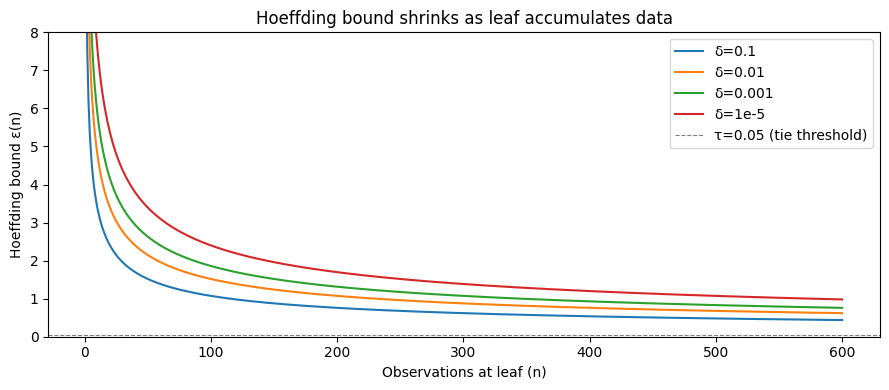

In [2]:
R = 10.0   # matches outcome_range default
deltas = {"δ=0.1": 0.1, "δ=0.01": 0.01, "δ=0.001": 0.001, "δ=1e-5": 1e-5}
ns = list(range(1, 601))

fig, ax = plt.subplots(figsize=(9, 4))
for label, delta in deltas.items():
    bounds = [math.sqrt(R**2 * math.log(1.0 / delta) / (2 * n)) for n in ns]
    ax.plot(ns, bounds, label=label)
ax.axhline(0.05, color="gray", linestyle="--", linewidth=0.8, label="τ=0.05 (tie threshold)")
ax.set_xlabel("Observations at leaf (n)")
ax.set_ylabel("Hoeffding bound ε(n)")
ax.set_title("Hoeffding bound shrinks as leaf accumulates data")
ax.set_ylim(0, 8)
ax.legend()
plt.tight_layout()

## 4. Step DGP: Where Trees Excel

Trees are optimal when the true CATE is **piecewise constant** — i.e. there exist
natural subgroups with different treatment effects. The `step` DGP creates exactly this:

$$\tau(x) = \begin{cases} 4.0 & \text{if } x_0 > 0 \\ 1.0 & \text{if } x_0 \le 0 \end{cases}$$

One clean split on $x_0$ at threshold 0 perfectly recovers both groups. The
between-child CATE variance at this split is $(0.5)(1.0 - 2.5)^2 + (0.5)(4.0-2.5)^2 = 2.25$,
which exceeds the Hoeffding bound (~1.5) at $n = 100$ — so the tree splits at the very
first `grace_period`.

In [3]:
STEP_PARAMS = dict(n=3000, true_ate=2.0, heterogeneity="step", seed=0)
stream_step = HeterogeneousCausalStream(**STEP_PARAMS)
pop_ate_step = stream_step.population_ate()

tree_step = CausalHoeffdingTree(grace_period=100, delta=0.01, max_depth=4)

print(f"{'n':>6} | {'n_nodes':>8} | {'n_leaves':>9} | {'ATE est':>9}")
print("-" * 42)
for i, (x, w, y, _) in enumerate(stream_step):
    tree_step.learn_one(x, w, y)
    if (i + 1) in {100, 200, 500, 1000, 2000, 3000}:
        print(f"{i+1:>6} | {tree_step.n_nodes:>8} | {tree_step.n_leaves:>9} | {tree_step.predict_ate():>9.3f}")
print(f"\nPopulation ATE: {pop_ate_step:.3f}")

     n |  n_nodes |  n_leaves |   ATE est
------------------------------------------
   100 |        1 |         1 |     1.730
   200 |        3 |         2 |     2.170
   500 |        3 |         2 |     2.449
  1000 |        3 |         2 |     2.563
  2000 |        3 |         2 |     2.606
  3000 |        3 |         2 |     2.581

Population ATE: 2.500


## 5. CATE Quality: Step DGP

On a step DGP, a tree with 2 leaves is the **correct model**. Compare predictions
from `CausalHoeffdingTree`, `OnlineCausalForest`, `CausalForestDML` (batch GRF from EconML),
and `OnlineRLearner`.

In [4]:
data_step = list(HeterogeneousCausalStream(**STEP_PARAMS))

# Online models
tree_s  = CausalHoeffdingTree(grace_period=100, delta=0.01, max_depth=4)
forest_s = OnlineCausalForest(n_trees=20, grace_period=100, delta=0.01, max_depth=4, seed=42)
rl_s    = OnlineRLearner(cate_model=LinearRegression())
for x, w, y, _ in data_step:
    tree_s.learn_one(x, w, y)
    forest_s.learn_one(x, w, y)
    rl_s.learn_one(x, w, y)

# Batch GRF (CausalForestDML from EconML)
X_s = np.array([[v for v in x.values()] for x, _, _, _ in data_step])
T_s = np.array([w for _, w, _, _ in data_step])
Y_s = np.array([y for _, _, y, _ in data_step])
grf_s = CausalForestDML(n_estimators=200, random_state=42, verbose=0)
grf_s.fit(Y_s, T_s, X=X_s)

# Evaluate on representative points
print(f"{'x0':>5} | {'True':>6} | {'CHT':>7} | {'Forest':>8} | {'GRF':>7} | {'R-Learn':>8}")
print("-" * 52)
for x0, true in [(-2.0, 1.0), (-0.5, 1.0), (+0.5, 4.0), (+2.0, 4.0)]:
    x_dict = {"x0": x0, "x1": 0.0, "x2": 0.0, "x3": 0.0, "x4": 0.0}
    x_arr  = np.array([[x0, 0.0, 0.0, 0.0, 0.0]])
    print(
        f"{x0:>+5.1f} | {true:>6.1f} | {tree_s.predict_one(x_dict):>7.3f} | "
        f"{forest_s.predict_one(x_dict):>8.3f} | {grf_s.effect(x_arr)[0]:>7.3f} | "
        f"{rl_s.predict_one(x_dict):>8.3f}"
    )

   x0 |   True |     CHT |   Forest |     GRF |  R-Learn
----------------------------------------------------
 -2.0 |    1.0 |   1.081 |    1.084 |   0.808 |    0.105
 -0.5 |    1.0 |   1.081 |    1.084 |   0.970 |    1.911
 +0.5 |    4.0 |   3.825 |    3.828 |   3.999 |    3.115
 +2.0 |    4.0 |   3.825 |    3.828 |   3.867 |    4.920


> **Observation:** On a step DGP, `CausalHoeffdingTree` and `OnlineCausalForest` are
> competitive with batch GRF while processing data in a single online pass.
> `OnlineRLearner` (linear model) struggles because it cannot capture the discrete jump.

## 6. Nonlinear DGP: Honest Comparison

On a **nonlinear DGP** ($\tau(x) = 2 + x_0 + \sin(x_1) \cdot 0.5$), the
CATE varies continuously. A tree with few leaves can only coarsely approximate this —
each leaf returns the average CATE of its member units, not a point estimate.
This is where smooth models (GRF, R-Learner) have a structural advantage.

In [5]:
NL_PARAMS = dict(n=3000, true_ate=2.0, heterogeneity="nonlinear", seed=0)
data_nl = list(HeterogeneousCausalStream(**NL_PARAMS))

# Online models
tree_nl   = CausalHoeffdingTree(grace_period=100, delta=0.01, max_depth=4)
forest_nl = OnlineCausalForest(n_trees=20, grace_period=100, delta=0.01, max_depth=4, seed=42)
rl_nl     = OnlineRLearner(cate_model=LinearRegression())
for x, w, y, _ in data_nl:
    tree_nl.learn_one(x, w, y)
    forest_nl.learn_one(x, w, y)
    rl_nl.learn_one(x, w, y)

# Batch GRF
X_nl = np.array([[v for v in x.values()] for x, _, _, _ in data_nl])
T_nl = np.array([w for _, w, _, _ in data_nl])
Y_nl = np.array([y for _, _, y, _ in data_nl])
grf_nl = CausalForestDML(n_estimators=200, random_state=42, verbose=0)
grf_nl.fit(Y_nl, T_nl, X=X_nl)

print(f"{'x0':>5} | {'True':>6} | {'CHT':>7} | {'Forest':>8} | {'GRF':>7} | {'R-Learn':>8}")
print("-" * 52)
for x0 in [-2.0, -1.0, 0.0, 1.0, 2.0]:
    true = 2.0 + x0 + math.sin(0.0) * 0.5
    x_dict = {"x0": x0, "x1": 0.0, "x2": 0.0, "x3": 0.0, "x4": 0.0}
    x_arr  = np.array([[x0, 0.0, 0.0, 0.0, 0.0]])
    print(
        f"{x0:>+5.1f} | {true:>6.3f} | {tree_nl.predict_one(x_dict):>7.3f} | "
        f"{forest_nl.predict_one(x_dict):>8.3f} | {grf_nl.effect(x_arr)[0]:>7.3f} | "
        f"{rl_nl.predict_one(x_dict):>8.3f}"
    )

# PEHE on held-out half
half = len(data_nl) // 2
pehe = {k: 0.0 for k in ["CHT", "Forest", "GRF", "RLearner"]}
for x, w, y, tau in data_nl[half:]:
    x_dict = x
    x_arr  = np.array([[x["x0"], x["x1"], x["x2"], x["x3"], x["x4"]]])
    pehe["CHT"]     += (tree_nl.predict_one(x_dict) - tau)**2
    pehe["Forest"]  += (forest_nl.predict_one(x_dict) - tau)**2
    pehe["GRF"]     += (grf_nl.effect(x_arr)[0] - tau)**2
    pehe["RLearner"]+= (rl_nl.predict_one(x_dict) - tau)**2
n_eval = half
print(f"\nPEHE (sqrt) on held-out n={n_eval}:")
for name, val in pehe.items():
    print(f"  {name:<10}: {(val/n_eval)**0.5:.4f}")

   x0 |   True |     CHT |   Forest |     GRF |  R-Learn
----------------------------------------------------
 -2.0 |  0.000 |   1.239 |    1.103 |  -0.245 |    0.003
 -1.0 |  1.000 |   1.239 |    1.103 |   0.911 |    1.052
 +0.0 |  2.000 |   2.853 |    2.472 |   1.802 |    2.102
 +1.0 |  3.000 |   2.853 |    2.950 |   2.664 |    3.151


 +2.0 |  4.000 |   2.853 |    2.950 |   3.589 |    4.200



PEHE (sqrt) on held-out n=1500:
  CHT       : 0.7034
  Forest    : 0.6581
  GRF       : 0.2261
  RLearner  : 0.3155


> **Observation:** On a smooth nonlinear DGP, GRF and R-Learner outperform the tree
> because they can represent continuous CATE variation. Trees are best when the
> ground truth is piecewise constant (discrete subgroups). The key advantage of
> `CausalHoeffdingTree` over batch GRF is that it operates in $O(d \cdot \text{leaves})$
> memory with a single streaming pass — no dataset storage required.

## 7. OnlineCausalForest — Poisson Bootstrap Ensemble

`OnlineCausalForest` runs `n_trees` independent `CausalHoeffdingTree` instances.
For each incoming observation, each tree $b$ receives the observation $k_b$ times:

$$k_b \sim \text{Poisson}(\lambda), \quad \lambda = \texttt{subsample\_rate} = 1.0$$

This is **online bagging** (Oza 2001): in the limit, $k \sim \text{Poisson}(1)$
approximates a bootstrap resample. The trees decorrelate because each sees a
slightly different view of the stream. The ensemble prediction averages across all trees.

Forest leaf counts: min=2, max=3, mean=2.1


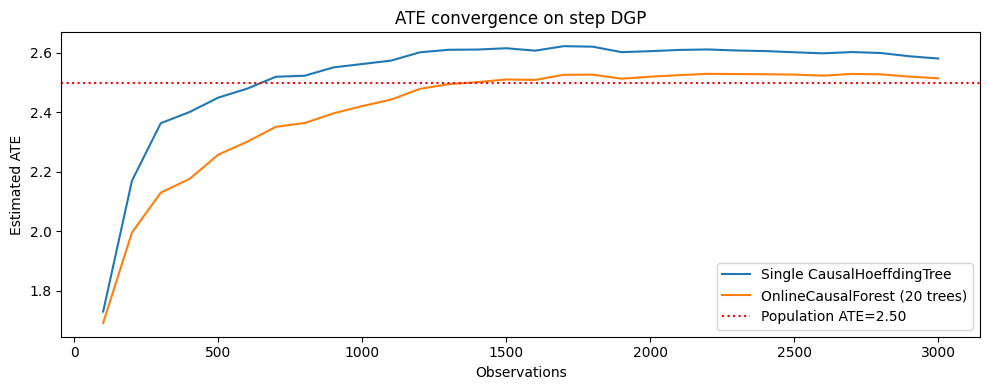

In [6]:
# ATE convergence comparison on step DGP
LOG_EVERY = 100
tree_ates, forest_ates = [], []
steps_log = []

tree_c   = CausalHoeffdingTree(grace_period=100, delta=0.01, max_depth=4)
forest_c = OnlineCausalForest(n_trees=20, grace_period=100, delta=0.01, max_depth=4, seed=0)

for i, (x, w, y, _) in enumerate(HeterogeneousCausalStream(**STEP_PARAMS)):
    tree_c.learn_one(x, w, y)
    forest_c.learn_one(x, w, y)
    if (i + 1) % LOG_EVERY == 0:
        steps_log.append(i + 1)
        tree_ates.append(tree_c.predict_ate())
        forest_ates.append(forest_c.predict_ate())

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps_log, tree_ates,   label="Single CausalHoeffdingTree")
ax.plot(steps_log, forest_ates, label="OnlineCausalForest (20 trees)")
ax.axhline(pop_ate_step, color="red", linestyle=":", label=f"Population ATE={pop_ate_step:.2f}")
ax.set_xlabel("Observations")
ax.set_ylabel("Estimated ATE")
ax.set_title("ATE convergence on step DGP")
ax.legend()
plt.tight_layout()

print(f"Forest leaf counts: min={min(forest_c.n_leaves)}, "
      f"max={max(forest_c.n_leaves)}, mean={statistics.mean(forest_c.n_leaves):.1f}")

## 8. Parameter Sensitivity

How `grace_period` and `delta` affect tree depth and ATE accuracy on the step DGP.

In [7]:
print("grace_period effect (step DGP, n=3000, delta=0.01):")
print(f"{'grace_period':>13} | {'n_leaves':>9} | {'ATE error':>10}")
print("-" * 38)
for gp in [50, 100, 200, 500]:
    t = CausalHoeffdingTree(grace_period=gp, delta=0.01, max_depth=4)
    for x, w, y, _ in HeterogeneousCausalStream(**STEP_PARAMS):
        t.learn_one(x, w, y)
    print(f"{gp:>13} | {t.n_leaves:>9} | {abs(t.predict_ate() - pop_ate_step):>10.4f}")

print()
print("delta effect (step DGP, n=3000, grace_period=100):")
print(f"{'delta':>10} | {'n_leaves':>9} | {'ATE error':>10}")
print("-" * 35)
for delta in [0.5, 0.1, 0.01, 0.001, 1e-5]:
    t = CausalHoeffdingTree(grace_period=100, delta=delta, max_depth=4)
    for x, w, y, _ in HeterogeneousCausalStream(**STEP_PARAMS):
        t.learn_one(x, w, y)
    print(f"{delta:>10.5f} | {t.n_leaves:>9} | {abs(t.predict_ate() - pop_ate_step):>10.4f}")

grace_period effect (step DGP, n=3000, delta=0.01):
 grace_period |  n_leaves |  ATE error
--------------------------------------
           50 |         2 |     0.0809
          100 |         2 |     0.0809
          200 |         2 |     0.0573
          500 |         2 |     0.0267

delta effect (step DGP, n=3000, grace_period=100):
     delta |  n_leaves |  ATE error
-----------------------------------
   0.50000 |         2 |     0.0814


   0.10000 |         2 |     0.0814
   0.01000 |         2 |     0.0809
   0.00100 |         2 |     0.0694
   0.00001 |         2 |     0.0325


## Summary

### When to use which method

| DGP type | Best online method | Best batch method |
|---|---|---|
| Step / discrete subgroups | `CausalHoeffdingTree` | `CausalForestDML` (GRF) |
| Smooth / continuous CATE | `OnlineRLearner` | `CausalForestDML` (GRF) |
| Unknown / mixed | `OnlineCausalForest` | `CausalForestDML` (GRF) |
| Streaming, memory-constrained | Any online method | N/A |

### Key parameters

| Parameter | Effect | Guidance |
|---|---|---|
| `grace_period` | Min obs before split attempt | 50–200; larger = more conservative |
| `delta` | Split confidence | 0.01–0.001 typical; smaller = rarer splits |
| `tau` | Tie-breaking threshold | 0.05 default |
| `max_depth` | Max tree depth | 3–5 for interpretability; more for accuracy |
| `n_trees` | Forest ensemble size | 10–20 sufficient |
| `outcome_range` | Hoeffding bound scale | Set to expected `max(|CATE|)` |

### Online vs batch (GRF)

| Property | `OnlineCausalForest` | `CausalForestDML` (batch GRF) |
|---|---|---|
| Memory | $O(d \cdot \text{leaves} \cdot B)$ | $O(n)$ |
| Passes over data | 1 | 1 (but stores all data) |
| Drift adaptation | ✓ (via `reset()` or `forgetting_factor`) | ✗ static |
| CATE accuracy (step DGP) | Competitive | Strong |
| CATE accuracy (smooth DGP) | Weaker | Stronger |
| Semiparametric theory | Approximation | Cross-fitted, honest |